In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

import matplotlib.font_manager as fm
import polars as pl 

In [2]:
try:
    sns.set_theme(
        style='whitegrid',
        font='Libertinus Serif',
        font_scale=2,
        rc={
            'axes.facecolor': 'white',
            'figure.facecolor': 'white',
            'mathtext.fontset': 'custom',
            'mathtext.rm': 'Libertinus Serif',
            'mathtext.it': 'Libertinus Serif:italic',
            'mathtext.bf': 'Libertinus Serif:bold',
            'text.usetex': True,
            'font.family': 'serif',
            'font.serif': ['Libertinus Serif'],
        }
    )
except Exception as e:
    print(f"Could not set custom font: {e}")
    sns.set_theme(
        style='whitegrid',
        font_scale=2,
        rc={
            'axes.facecolor': 'white',
            'figure.facecolor': 'white',
        }
    )

In [3]:
df = pl.read_csv("../results/all_experiments_results_float64.csv")

In [4]:
# define what to plot and how 
configs = {
    "e_fdm": {
        'metric': 'e_fdm_vs_true_l2',
        'label': r'$e_{\mathrm{FDM}}$ (FDM Est.)',
        'linestyle': '-',
        'marker': 'o',
        'alpha': 1.0,
        'color': "#ff7f00",
        'num_domain': 10_000,
        'n_iter': 10_000,
        'linewidth': 4,
    },
    "e_res_good": {
        'metric': 'e_res_vs_true_l2',
        'label': r'$e_{\mathrm{res}}$ (Ours, Well-trained)',
        'linestyle': '-',
        'marker': 'o',
        'alpha': 1.0,
        'color': "#377eb8",
        'num_domain': 10_000,
        'n_iter': 10_000,
        'linewidth': 2.5,
    },
    "e_res_random": {
        'metric': 'e_res_vs_true_l2',
        'label': r'$e_{\mathrm{res}}$ (Ours, Random Init.)',
        'linestyle': '--',
        'marker': 's',
        'alpha': 1.0,
        'color': "#377eb8",
        'num_domain': 10_000,
        'n_iter': 0,
        'linewidth': 2.5,
    },
}

In [5]:
problems = ['poisson_1d', 'poisson_2d', 'heat', 'drift_diffusion', 'wave']
problem_labels = ['Poisson 1D', 'Poisson 2D', 'Heat', 'Drift-Diffusion', 'Wave']

# filter grids - set to None to include all 
GRID_FILTER = None
# GRID_FILTER = [8, 16, 32, 64, 128, 256]  

# recovers relevant subset of data
def get_filtered_df(df, problem, metric, n_iter, num_domain=10_000):
    df = df.filter(pl.col('seed') < 10)
    if problem == 'poisson_1d':
        filtered = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('n_iterations') == n_iter) &
            (pl.col('num_domain') == num_domain)
        )
    elif problem == 'poisson_2d':
        filtered = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('n_iterations') == n_iter) &
            (pl.col('num_domain') == num_domain) &
            (pl.col('nx') == pl.col('ny')) 
        )
    else:
        filtered = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('n_iterations') == n_iter) &
            (pl.col('num_domain') == num_domain) &
            (pl.col('nx') == pl.col('nt')) 
        )
    return filtered.select(pl.col(metric), pl.col('nx')).to_pandas()

def plot_convergence(df, save_path=None):
    for problem, label in zip(problems, problem_labels):
        fig, ax = plt.subplots(1, 1)

        for config_name in ['e_fdm', 'e_res_good', 'e_res_random']:
            config = configs[config_name]
            metric = config['metric']
            n_iter = config['n_iter']
            num_domain = config['num_domain']

            # retrieve current dataframe 
            df_filtered = get_filtered_df(df, problem, metric, n_iter, num_domain)
            if df_filtered.shape[0] > 0:
                # plot current data with standard deviations
                sns.lineplot(
                    data=df_filtered,
                    x='nx', 
                    y=metric,
                    ax=ax,
                    color=config['color'],
                    linestyle=config['linestyle'],
                    marker=config['marker'],
                    markersize=5,
                    linewidth=config['linewidth'],
                    alpha=config['alpha'],
                    errorbar='sd'
                )

        suffix = " "
        if problem == 'poisson_1d':
            suffix = "($N_x$)"
        elif problem == 'poisson_2d':
            suffix = "($N_x=N_y$)"
        elif problem in ['heat', 'drift_diffusion', 'wave']:
            suffix = "($N_x=N_t$)"
        ax.set_xlabel(f'Grid size {suffix}')
        ax.set_yscale('log')
        ax.set_xscale('log', base=2)
        ax.set_xticks(df_filtered['nx'].sort_values().unique())
        ax.set_xticklabels(df_filtered['nx'].sort_values().unique())
        ax.set_ylabel(None)
        ax.grid(alpha=0.3)

        if problem == 'poisson_1d':
            ax.set_ylabel(r'$L_2$ Error')

        plt.tight_layout()

        if save_path:
            fig.savefig(save_path.replace('.pdf', f'_{problem}.pdf'), bbox_inches='tight')
        
        ax.set_title(label)


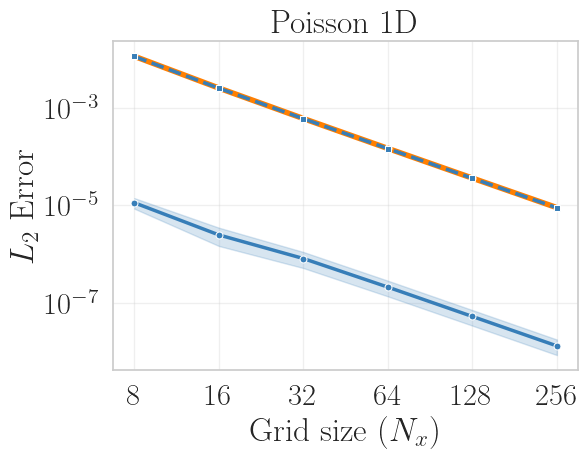

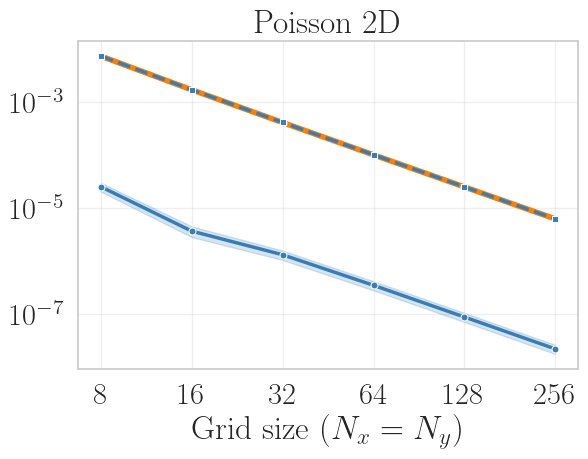

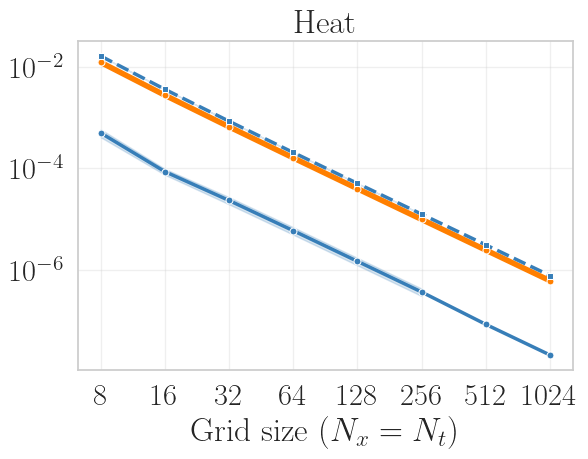

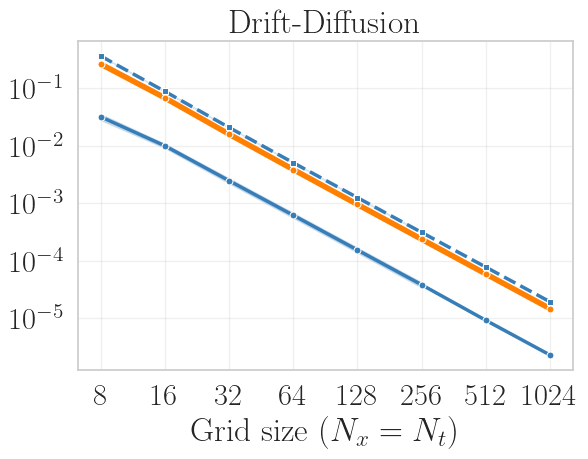

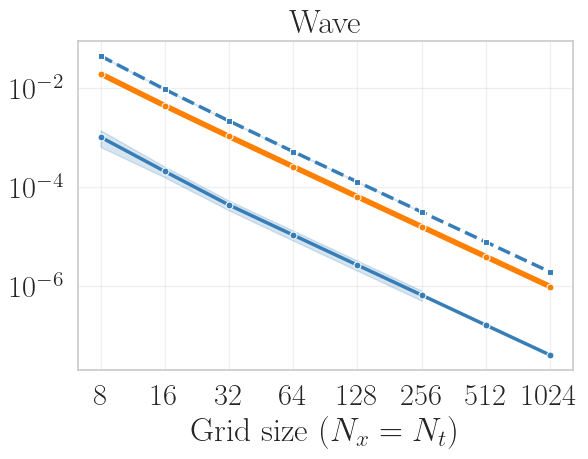

In [6]:
plot_convergence(df, "../figures/comp_plots/comparison.pdf")

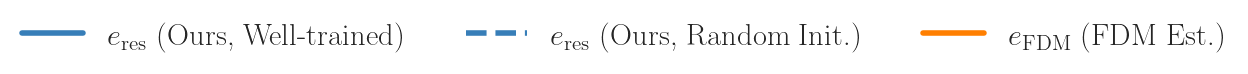

In [7]:
import matplotlib.lines as mlines

legend_handles = []

for config_name in ['e_res_good', 'e_res_random', 'e_fdm']:
    config = configs[config_name]
    legend_handles.append(
        mlines.Line2D([], [], color=config['color'], linestyle=config['linestyle'], lw=4, label=config['label'])
    )

fig_legend, ax_legend = plt.subplots(figsize=(12, 0.4))
ax_legend.axis('off')
fig_legend.legend(
    handles=legend_handles,
    loc='center',
    ncol=4,
    frameon=False,
)

fig_legend.savefig("../figures/comp_plots/legend.pdf", bbox_inches='tight', pad_inches=0.05)